 # CUSTOMER CHURN PREDICTION MODEL COMPARISON # Algorithms:
Decision Tree, Random Forest, XGBoost, Gradient Boosting # Dataset: Telco Customer
Churn (Real-world dataset)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve,StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,roc_auc_score, roc_curve, confusion_matrix,classification_report)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("CUSTOMER CHURN PREDICTION MODEL COMPARISON")


CUSTOMER CHURN PREDICTION MODEL COMPARISON


In [3]:
import pandas as pd
import numpy as np

# CUSTOMER CHURN PREDICTION MODEL COMPARISON
print("\nStep 1: Loading Dataset...")

# Kaggle dataset page
url = "https://www.kaggle.com/datasets/blastchar/telco-customer-churn"

try:
    # Replace with your local CSV file after downloading from Kaggle
    df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
    print(f"Dataset loaded successfully! Shape: {df.shape}")

except Exception:
    print("Error loading dataset. Please download manually from:")
    print(url)

    print("\nUsing sample data for demonstration...")

    # Fallback: Create sample dataset
    np.random.seed(42)
    n_samples = 1000

    df = pd.DataFrame({
        'tenure': np.random.randint(1, 72, n_samples),
        'MonthlyCharges': np.random.uniform(20, 120, n_samples),
        'Contract': np.random.choice(
            ['Month-to-month', 'One year', 'Two year'],
            n_samples
        ),
        'InternetService': np.random.choice(
            ['DSL', 'Fiber optic', 'No'],
            n_samples
        ),
        'TechSupport': np.random.choice(
            ['Yes', 'No', 'No internet service'],
            n_samples
        ),
        'PaymentMethod': np.random.choice(
            ['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'],
            n_samples
        ),
        'SeniorCitizen': np.random.choice([0, 1], n_samples),
        'Partner': np.random.choice(['Yes', 'No'], n_samples),
        'Churn': np.random.choice(
            ['Yes', 'No'],
            n_samples,
            p=[0.27, 0.73]
        )
    })

print("\nDataset Info:")
print(f" - Total records: {len(df)}")
print(f" - Features: {df.shape[1] - 1}")
print(f" - Missing values: {df.isnull().sum().sum()}")


Step 1: Loading Dataset...
Error loading dataset. Please download manually from:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Using sample data for demonstration...

Dataset Info:
 - Total records: 1000
 - Features: 8
 - Missing values: 0



 Step 2: Exploratory Data Analysis...

Basic Dataset Info:
 - Missing values: 0
 - Duplicate rows: 0
 - Churn rate: 28.40%


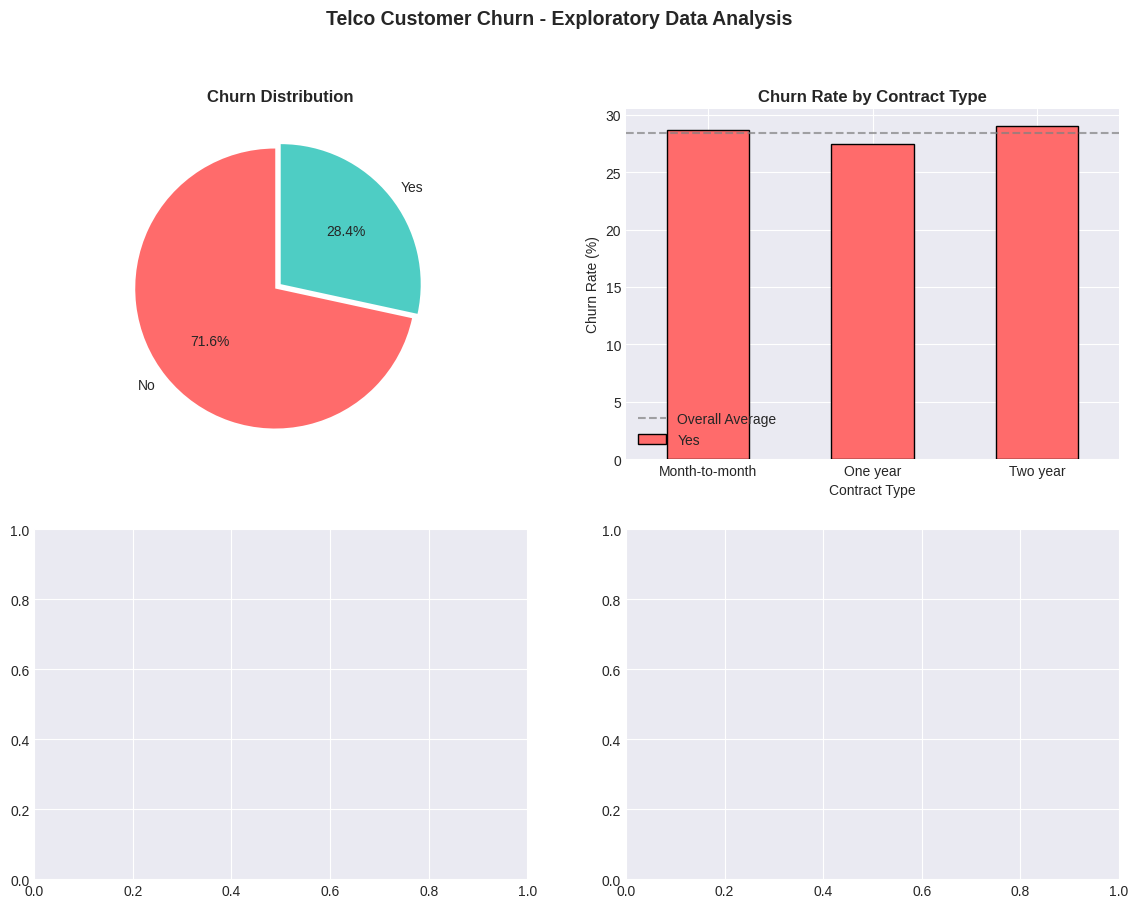

In [4]:
print("\n Step 2: Exploratory Data Analysis...")
# Basic statistics
print("\nBasic Dataset Info:")
print(f" - Missing values: {df.isnull().sum().sum()}")
print(f" - Duplicate rows: {df.duplicated().sum()}")
print(f" - Churn rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telco Customer Churn - Exploratory Data Analysis',
fontsize=14, fontweight='bold')
# 1. Churn Distribution
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(churn_counts.values, labels=churn_counts.index,
autopct='%1.1f%%',
colors=['#ff6b6b', '#4ecdc4'], explode=[0.05, 0],
startangle=90)
axes[0, 0].set_title('Churn Distribution', fontweight='bold')
# 2. Churn by Contract Type
contract_churn = pd.crosstab(df['Contract'], df['Churn'],
normalize='index') * 100
contract_churn['Yes'].plot(kind='bar', ax=axes[0, 1], color='#ff6b6b',
edgecolor='black')
axes[0, 1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].axhline(y=(df['Churn'] == 'Yes').mean() * 100, color='gray',
linestyle='--',
label='Overall Average', alpha=0.7)
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=0)


 Step 2: Exploratory Data Analysis...

Basic Dataset Info:
 - Missing values: 0
 - Duplicate rows: 0
 - Churn rate: 28.40%


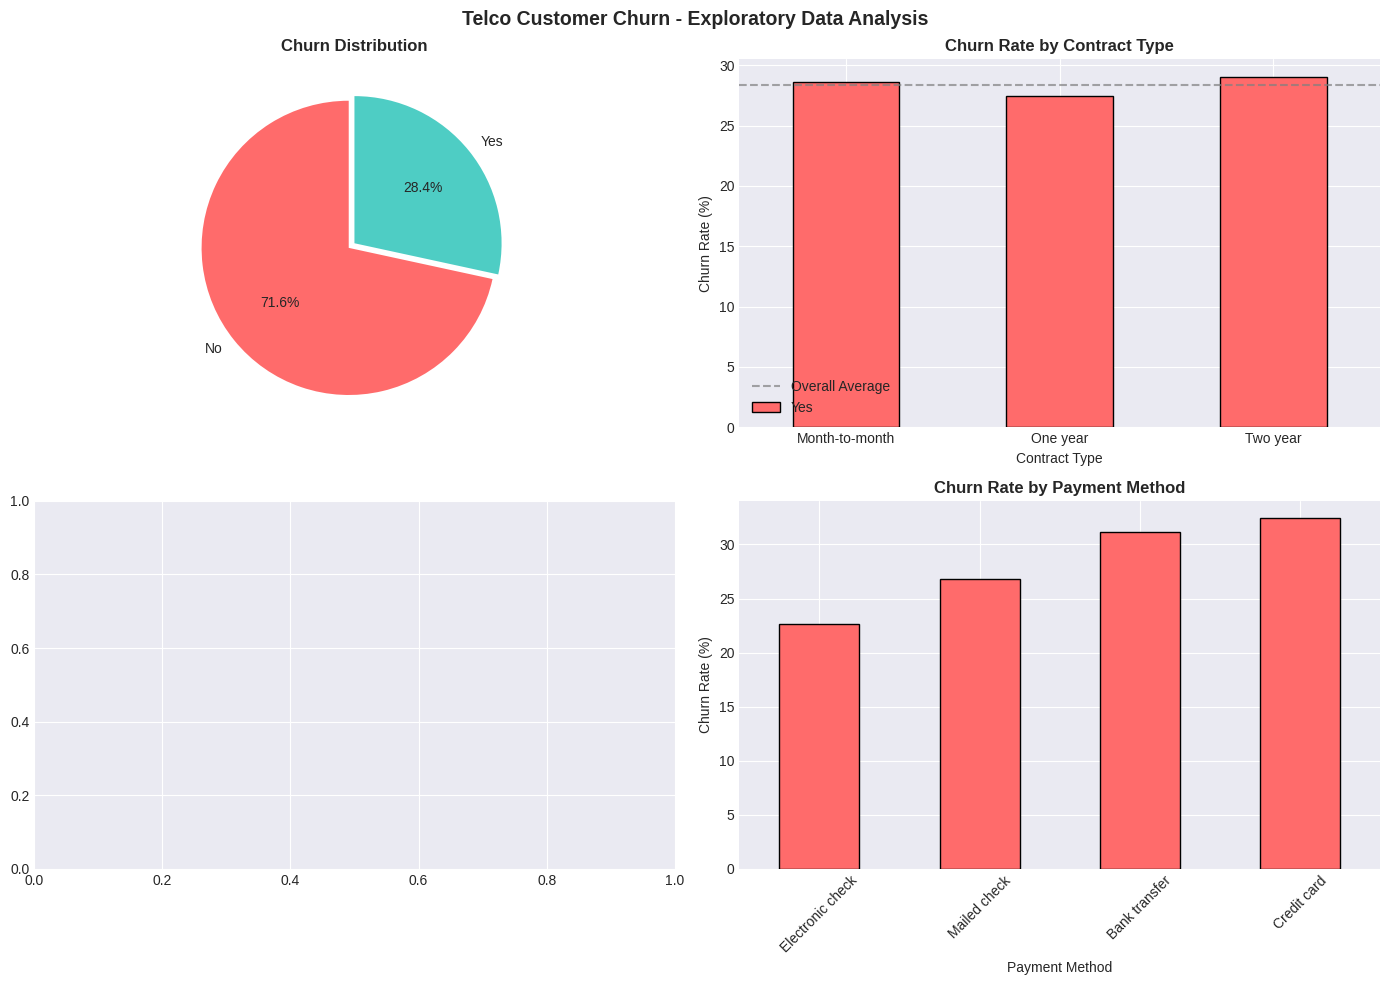

In [5]:
print("\n Step 2: Exploratory Data Analysis...")
# Basic statistics
print("\nBasic Dataset Info:")
print(f" - Missing values: {df.isnull().sum().sum()}")
print(f" - Duplicate rows: {df.duplicated().sum()}")
print(f" - Churn rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telco Customer Churn - Exploratory Data Analysis',
fontsize=14, fontweight='bold')
# 1. Churn Distribution
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(churn_counts.values, labels=churn_counts.index,
autopct='%1.1f%%',
colors=['#ff6b6b', '#4ecdc4'], explode=[0.05, 0],
startangle=90)
axes[0, 0].set_title('Churn Distribution', fontweight='bold')
# 2. Churn by Contract Type
contract_churn = pd.crosstab(df['Contract'], df['Churn'],
normalize='index') * 100
contract_churn['Yes'].plot(kind='bar', ax=axes[0, 1], color='#ff6b6b',
edgecolor='black')
axes[0, 1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].axhline(y=(df['Churn'] == 'Yes').mean() * 100, color='gray',
linestyle='--',
label='Overall Average', alpha=0.7)
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=0)
# 4. Churn by Payment Method
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'],
normalize='index') * 100
payment_churn['Yes'].sort_values().plot(kind='bar', ax=axes[1, 1],
color='#ff6b6b', edgecolor='black')
axes[1, 1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xlabel('Payment Method')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# 4. Churn by Payment Method
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'],
normalize='index') * 100
payment_churn['Yes'].sort_values().plot(kind='bar', ax=axes[1, 1],
color='#ff6b6b', edgecolor='black')
axes[1, 1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate (%)')
axes[1, 1].set_xlabel('Payment Method')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# ============================================
# 3. DATA PREPROCESSING
# ============================================

print("\nStep 3: Data Preprocessing...")

# Create a clean copy for modeling
df_model = df.copy()

# Drop customerID (not useful for prediction)
if 'customerID' in df_model.columns:
    df_model = df_model.drop('customerID', axis=1)

# Remove temporary tenure_group column if it exists
if 'tenure_group' in df_model.columns:
    df_model = df_model.drop('tenure_group', axis=1)

# Convert TotalCharges to numeric (it might contain empty strings)
if 'TotalCharges' in df_model.columns:
    df_model['TotalCharges'] = pd.to_numeric(
        df_model['TotalCharges'],
        errors='coerce'
    )

    # Fill missing TotalCharges with MonthlyCharges
    df_model['TotalCharges'].fillna(
        df_model['MonthlyCharges'],
        inplace=True
    )

# Separate features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n- Numerical features ({len(numerical_cols)}):")
print(numerical_cols)

print(f"\n- Categorical features ({len(categorical_cols)}):")
print(categorical_cols)

# Encode categorical variables
print("\nEncoding categorical variables...")

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

    print(f"\n✓ {col}:")
    print(dict(zip(le.classes_, le.transform(le.classes_))))

# Scale numerical features
print("\nScaling numerical features...")

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Verify all data is numeric
print("\nData validation:")

print(
    f"- All features numeric: "
    f"{all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns)}"
)

print(f"- Missing values: {X.isnull().sum().sum()}")
print(f"- Data types: {X.dtypes.unique()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nClass distribution (training):")
print(f"- No Churn: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"- Churn: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")


Step 3: Data Preprocessing...

- Numerical features (3):
['tenure', 'MonthlyCharges', 'SeniorCitizen']

- Categorical features (5):
['Contract', 'InternetService', 'TechSupport', 'PaymentMethod', 'Partner']

Encoding categorical variables...

✓ Contract:
{'Month-to-month': np.int64(0), 'One year': np.int64(1), 'Two year': np.int64(2)}

✓ InternetService:
{'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}

✓ TechSupport:
{'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}

✓ PaymentMethod:
{'Bank transfer': np.int64(0), 'Credit card': np.int64(1), 'Electronic check': np.int64(2), 'Mailed check': np.int64(3)}

✓ Partner:
{'No': np.int64(0), 'Yes': np.int64(1)}

Scaling numerical features...

Data validation:
- All features numeric: True
- Missing values: 0
- Data types: [dtype('float64') dtype('int64')]

Training set: 800 samples
Test set: 200 samples

Class distribution (training):
- No Churn: 573 (71.6%)
- Churn: 227 (28.4%)


In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import xgboost as xgb

# ============================================
# 4. MODEL TRAINING
# ============================================

print("\nStep 4: Training Models...")

models = {
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_split=20
    ),

    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=10,
        min_samples_split=20,
        n_jobs=-1
    ),

    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='logloss'
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1
    )
}

results = {}
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    try:
        # Train model
        model.fit(X_train, y_train)
        trained_models[name] = model

        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Evaluation metrics
        results[name] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
        }

        print(f"✓ Accuracy : {results[name]['Accuracy']:.4f}")
        print(f"✓ Precision: {results[name]['Precision']:.4f}")
        print(f"✓ Recall   : {results[name]['Recall']:.4f}")
        print(f"✓ F1-Score : {results[name]['F1-Score']:.4f}")
        print(f"✓ ROC-AUC  : {results[name]['ROC-AUC']:.4f}")

    except Exception as e:
        print(f"✗ Error: {e}")

        results[name] = {
            'Accuracy': 0,
            'Precision': 0,
            'Recall': 0,
            'F1-Score': 0,
            'ROC-AUC': 0
        }


Step 4: Training Models...

Training Decision Tree...
✗ Error: name 'X_train' is not defined

Training Random Forest...
✗ Error: name 'X_train' is not defined

Training XGBoost...
✗ Error: name 'X_train' is not defined

Training Gradient Boosting...
✗ Error: name 'X_train' is not defined
